In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Lectura de datos
datos = pd.read_csv("datos_mw_conv_final_ohe.csv")
df = datos.copy() # as.data.frame no es estrictamente necesario, pandas ya usa DataFrames

# 2. Suavizar con logaritmo la energía
# np.log1p(x) es el equivalente exacto y optimizado matemáticamente para log(x + 1)
cols_log = [
    'energia_acumulada_diaria', 'energia_lag1', 
    'roll7_energia', 'roll30_energia', 'adj_roll30_energia'
]
df[cols_log] = np.log1p(df[cols_log])

# 3. Estandarización de las variables numéricas
listconti = [
    "eq_count", "energia_acumulada_diaria", "main_mag", "main_depth", "main_lat", 
    "main_lon", "magError", "depthError", "horizontalError", "nst", "gap", "dmin", 
    "rms", "magNst", "is_converted_mag", "lat_bin", "lon_bin", "b_value_daily", 
    "lag1_mag_max", "lag1_eq_count", "energia_lag1", "roll7_eq_count", "roll30_eq_count", 
    "roll7_mag_max", "roll30_mag_max", "roll7_energia", "roll30_energia", 
    "days_since_last_eq", "TARGET_mag_max_next_7d", "lat", "lon", "adj_num_eqs_x", 
    "adj_max_mag_x", "adj_num_eqs_y", "adj_max_mag_y", "adj_roll7_eq_count", 
    "adj_roll7_mag_max", "adj_roll30_energia", "adj_roll30_eq_count", "adj_roll30_mag_max"
]

scaler = StandardScaler()
df[listconti] = scaler.fit_transform(df[listconti])

# 4. Convertir lógicas a numéricas
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)


# Asegurar que la columna 'date' es de tipo datetime para permitir cortes temporales
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)

# 5. División en train y test por corte de tiempo
train = df[df['date'] < "2019-01-01"].copy()
test  = df[df['date'] >= "2019-01-01"].copy()
def compute_target_reg_enc_30d(df):
    # Hacer una copia y resetear índices
    df = df.copy().reset_index(drop=True)
    
    # Crear columna con NaN
    df['target_reg_enc_30d'] = np.nan
    
    # Procesar cada cell_id
    for cell_id in df['cell_id'].unique():
        # Obtener índices del grupo actual
        group_mask = df['cell_id'] == cell_id
        group_indices = df[group_mask].index
        
        # Si el grupo está vacío, continuar
        if len(group_indices) == 0:
            continue
        
        # Ordenar por fecha dentro del grupo
        group_df = df.loc[group_indices].sort_values('date')
        
        # Calcular rolling mean
        try:
            rolling_result = (
                group_df
                .set_index('date')['TARGET_mag_max_next_7d']
                .rolling('30D', closed='left')
                .mean()
            )
            
            # Asignar resultados
            df.loc[group_indices, 'target_reg_enc_30d'] = rolling_result.to_numpy()
            
        except Exception as e:
            print(f"Error procesando cell_id {cell_id}: {e}")
            # Fallback: usar media simple
            df.loc[group_indices, 'target_reg_enc_30d'] = (
                group_df['TARGET_mag_max_next_7d']
                .shift(1)
                .rolling(window=30, min_periods=1)
                .mean()
                .to_numpy()
            )
    
    return df

# Aplicar
train = compute_target_reg_enc_30d(train)
train['target_reg_enc_30d'].fillna(train['TARGET_mag_max_next_7d'].mean(), inplace=True)

test = compute_target_reg_enc_30d(test)
test['target_reg_enc_30d'].fillna(test['TARGET_mag_max_next_7d'].mean(), inplace=True)

datetime64[ns]


C:\Users\longj\AppData\Local\Temp\ipykernel_24272\1189971163.py:91: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['target_reg_enc_30d'].fillna(train['TARGET_mag_max_next_7d'].mean(), inplace=True)
C:\Users\longj\AppData\Local\Temp\ipykernel_24272\1189971163.py:94: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting

In [2]:
mi_lista = [
    "target_reg_enc_30d", "roll7_energia", "roll30_mag_max", "roll30_energia",
    "adj_roll30_mag_max", "gap", "roll7_eq_count", "roll30_eq_count",
    "locationSource_ci", "adj_roll30_energia", "main_depth", "eq_count",
    "rms", "days_since_last_eq", "lat"
]

In [3]:
# Preparar datos
X_train = train[mi_lista]
y_train = train["TARGET_mag_max_next_7d"]  # o TARGET_occurrence_M4.5 según el objetivo

X_test = test[mi_lista]
y_test = test["TARGET_mag_max_next_7d"] 

In [4]:
tuneo = df[(df['date'] < "2019-01-01") & (df['date'] >= "2018-01-01")].copy()
tuneo = compute_target_reg_enc_30d(tuneo)
tuneo['target_reg_enc_30d'].fillna(tuneo['TARGET_mag_max_next_7d'].mean(), inplace=True)

C:\Users\longj\AppData\Local\Temp\ipykernel_24272\381083478.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  tuneo['target_reg_enc_30d'].fillna(tuneo['TARGET_mag_max_next_7d'].mean(), inplace=True)


In [5]:
X_tuneo = tuneo[mi_lista]
y_tuneo = tuneo["TARGET_mag_max_next_7d"]

In [ ]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, make_scorer

# 1. TimeSeriesSplit para datos temporales
tscv = TimeSeriesSplit(n_splits=5)

# 2. Definir grid de parámetros SOLO con los 3 que te interesan
param_grid = {
    'hidden_layer_sizes': [
        (1,),         # 50 nodos totales
        (3,),        # 100 nodos totales
        (7,),        # 150 nodos totales
        (10,),        # 200 nodos totales ← máximo permitido
        (30, ),      # 100 nodos totales
        (60, ),     # 150 nodos totales
        (100,),     # 150 nodos totales
        (150,),    # 200 nodos totales ← máximo en 2 capas
    ],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'max_iter': [100, 200, 300, 500, 1000,2000],
}

# 3. Crear scorer (MSE negativo porque busca maximizar)
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# 4. Configurar RandomizedSearchCV
grid_search = GridSearchCV(  # 🔥 Cambiado a GridSearchCV
    MLPRegressor(
        random_state=42, 
        activation='relu',
        learning_rate_init=0.001,
        early_stopping=True,
        n_iter_no_change=10,
        solver='adam'
    ),
    param_grid=param_grid,  # 🔥 Usar param_grid (no param_distributions)
    cv=tscv,                          
    scoring=mse_scorer,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
    # ❌ NO tiene n_iter (prueba TODAS las combinaciones)
)

# 5. Ejecutar Tuneo
print("🔍 Tuneando hidden_layer_sizes, alpha y max_iter...")
grid_search.fit(X_tuneo, y_tuneo)

# 6. Mostrar resultados
best_mse_val = -grid_search.best_score_
print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor MSE (en validación): {best_mse_val:.4f}")

# Guardar el mejor modelo
best_nn = grid_search.best_estimator_

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Gráfico 1: Rendimiento de las configuraciones
# ==========================================
# Extraer resultados a un DataFrame de Pandas
results = pd.DataFrame(grid_search.cv_results_)
# Convertir el score negativo a positivo para interpretar el Error (MSE) real
if 'mean_test_MSE' in results.columns:
    results['mean_test_MSE'] = -results['mean_test_MSE']
elif 'mean_test_score' in results.columns:
    results['mean_test_MSE'] = -results['mean_test_score']
else:
    raise KeyError("cv_results_ no tiene ni 'mean_test_MSE' ni 'mean_test_score'")
# Ordenar de mejor a peor (menor error a mayor error)
results = results.sort_values('mean_test_MSE').reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(results.index, results['mean_test_MSE'], marker='o', linestyle='-', color='#1f77b4')
plt.title('Rendimiento de las Configuraciones de la Red Neuronal')
plt.xlabel('Índice de Configuración (Ordenadas de Mejor a Peor)')
plt.ylabel('Mean Squared Error (Validación cruzada)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================
# Gráfico 2: Top 10 Mejores Hiperparámetros
# ==========================================
top_10 = results.head(20).copy()
# Crear una etiqueta rápida para leer las configuraciones en el gráfico
top_10['params_str'] = top_10['params'].apply(
    lambda x: f"Capas: {x['hidden_layer_sizes']} | alpha: {x['alpha']} | max_iter: {x['max_iter']}"
)

plt.figure(figsize=(10, 6))
sns.barplot(x='mean_test_MSE', y='params_str', data=top_10, palette='viridis')
plt.title('Top 20 Mejores Configuraciones (Menor Error es Mejor)')
plt.xlabel('Mean Squared Error (MSE)')
plt.ylabel('Hiperparámetros')
plt.tight_layout()
plt.show()

# ==========================================
# Gráfico 3: Predicciones vs Reales (Test Set)
# ==========================================
# Hacer la predicción en el conjunto de prueba
y_pred = best_nn.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred)
print(f"📈 MSE final en Test Set: {mse_test:.4f}")

plt.figure(figsize=(14, 5))
# Si y_test es un DataFrame/Series de pandas, es mejor pasar sus valores
y_test_vals = y_test.values if hasattr(y_test, 'values') else y_test

plt.plot(y_test_vals, label='Datos Reales', color='black', alpha=0.6, linewidth=2)
plt.plot(y_pred, label='Predicciones (Red Neuronal)', color='red', alpha=0.8, linestyle='--')
plt.title('Red Neuronal: Datos Reales vs Predicciones en Set de Prueba')
plt.xlabel('Puntos de Tiempo')
plt.ylabel('Valor de la Variable Objetivo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualizar_grid_rmse(grid_search):
    # 1. Configurar el fondo gris típico de "ggplot" (como en tu imagen)
    plt.style.use('ggplot')
    
    # 2. Convertir el diccionario de resultados a un DataFrame de Pandas
    resultados = pd.DataFrame(grid_search.cv_results_)
    
    # 3. Extraer y formatear los parámetros. 
    # Usamos .astype(str) para simular la función "factor()" de R. 
    # Esto asegura que el eje X tenga la misma separación aunque los números den saltos.
    resultados['factor(itera)'] = resultados['param_max_iter'].astype(str)
    resultados['factor(decay)'] = resultados['param_alpha'].astype(float)
    resultados['factor(size)'] = resultados['param_hidden_layer_sizes'].astype(str)
    
    # 4. Obtener el RMSE
    # Si en tu GridSearchCV usaste scoring='neg_root_mean_squared_error',
    # los resultados son negativos. Los multiplicamos por -1 para tener el RMSE real.
    resultados['MSE'] = -resultados['mean_test_score']
    
    # 5. Crear el lienzo del gráfico
    plt.figure(figsize=(10, 7))
    
    # 6. Dibujar el Scatter Plot con Seaborn
    sns.scatterplot(
        data=resultados,
        x='factor(itera)',
        y='MSE',
        hue='factor(decay)',   # Controla el color según el decay
        style='factor(size)',  # Controla la figura (círculo, cuadrado, cruz) según las neuronas
        palette='husl',        # Paleta de color similar a la imagen
        s=80                   # Tamaño de los puntos
    )
    
    # 7. Detalles del gráfico (Mover la leyenda a la derecha como en tu foto)
    plt.title('Rendimiento Red Neuronal: MSE vs Iteraciones y Decay')
    plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0.)
    plt.tight_layout()
    
    # Mostrar el gráfico
    plt.show()

# Para llamarlo solo tienes que pasarle tu modelo previamente entrenado:
visualizar_grid_rmse(grid_search)

In [ ]:
def visualizar_grid_rmse_filtrado(grid_search, iteraciones=None):
    """
    Args:
        grid_search: objeto GridSearchCV
        iteraciones: lista con los valores de max_iter a incluir
                     Ej: [100, 200, 500] o [200] para uno solo
    """
    plt.style.use('ggplot')
    resultados = pd.DataFrame(grid_search.cv_results_)
    
    resultados['factor(itera)'] = resultados['param_max_iter'].astype(str)
    resultados['factor(decay)'] = resultados['param_alpha'].astype(float)
    resultados['factor(size)'] = resultados['param_hidden_layer_sizes'].astype(str)
    resultados['MSE'] = -resultados['mean_test_score']
    
    # 🔍 FILTRO: seleccionar solo ciertas iteraciones
    if iteraciones is not None:
        # Convertir iteraciones a lista si es un solo número
        if not isinstance(iteraciones, list):
            iteraciones = [iteraciones]
        # Filtrar el DataFrame
        resultados = resultados[resultados['param_max_iter'].isin(iteraciones)]
        
        # Verificar si hay datos después del filtro
        if len(resultados) == 0:
            print(f"⚠️ No se encontraron resultados para iteraciones: {iteraciones}")
            return
    
    plt.figure(figsize=(10, 7))
    
    sns.scatterplot(
        data=resultados,
        x='factor(size)',
        y='MSE',
        hue='factor(decay)',
        palette='husl',
        s=80
    )
    
    # Añadir título informativo
    if iteraciones:
        titulo = f'Rendimiento Red Neuronal: MSE vs Iteraciones {iteraciones} y Decay'
    else:
        titulo = 'Rendimiento Red Neuronal: MSE vs Iteraciones y Decay'
    
    plt.title(titulo)
    plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

# Uso:
visualizar_grid_rmse_filtrado(grid_search, iteraciones=[100])  # Solo iteraciones 100 y 200

In [ ]:
param_grid = {
    'hidden_layer_sizes': [(10,)],
    'alpha': [0.1],
    'max_iter': [100],
}
scoring = {
    'MSE': 'neg_mean_squared_error',
    'MAE': 'neg_mean_absolute_error', 
    'R2': 'r2'
}
print("🔍 Tuneando Red Neuronal con TimeSeriesSplit...")
grid_search = GridSearchCV(
    MLPRegressor(random_state=42, activation='relu', learning_rate_init=0.001, early_stopping=True, n_iter_no_change=10, solver='adam'),
    param_grid,
    cv=tscv,
    scoring=scoring,
    refit='MSE',
    n_jobs=-1,
    verbose=2,
    return_train_score=True 
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor MSE (validación): {grid_search.best_score_:.4f}")

# Evaluar en test
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# PASO 5: Comparar con validación cruzada
print(f"RMSE CV: {np.sqrt(-grid_search.best_score_):.4f}")
print(f"RMSE Test: {rmse:.4f}")

In [ ]:
grid_search_results = pd.DataFrame(grid_search.cv_results_)

In [ ]:
print(grid_search_results[['param_hidden_layer_sizes',
                           'param_alpha',
                           'param_max_iter',
                           'mean_test_MSE',
                           'std_test_MSE',
                           'mean_test_MAE',
                           'std_test_MAE',
                           'mean_test_R2',
                           'std_test_R2']])

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 2. Función para calcular métricas base
def calcular_metricas(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
            'RMSE': np.sqrt(mse),
            'MSE': mse,
            'MAE': mean_absolute_error(y_true, y_pred),
            'R2': r2_score(y_true, y_pred),
            'MAPE': np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # Porcentaje
        }

In [ ]:
y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

metricas_train = calcular_metricas(y_train, y_pred_train)
metricas_test = calcular_metricas(y_test, y_pred_test)

In [ ]:
print(metricas_train)
print(metricas_test)

Random Forest


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import numpy as np

# A diferencia de un GridSearch, para decidir n_estimators
# es mejor entrenar un RandomForest con warm_start=True
# para añadir árboles iterativamente y registrar el OOB error.

min_estimators = 1
max_estimators = 400

rf = RandomForestRegressor(
    n_estimators=1,
    oob_score=True,       # ¡Importante para calcular el error OOB!
    random_state=42,
    warm_start=True,      # Permite añadir árboles al bosque ya entrenado
    n_jobs=-1
)

error_rate = []

for i in range(min_estimators, max_estimators + 1):
    rf.set_params(n_estimators=i)
    # Entrenar el modelo (con warm_start solo entrena el nuevo árbol)
    rf.fit(X_tuneo, y_tuneo)
    
    # Extraer el score (R^2 si es regresión) y convertirlo a error (1 - R^2)
    # o bien calcular RMSE de rf.oob_prediction_ y y_train
    oob_preds = rf.oob_prediction_
    
    # En las primeras iteraciones, algunos datos pueden no haber sido "OOB" nunca.
    # Aparecerán como NaN, así que filtramos esos valores.
    valid_mask = ~np.isnan(oob_preds)
    
    if np.any(valid_mask):
        # Calcular el RMSE solo con las predicciones válidas
        oob_rmse = np.sqrt(mean_squared_error(y_tuneo[valid_mask], oob_preds[valid_mask]))
    else:
        oob_rmse = np.nan
        
    error_rate.append((i, oob_rmse))

# Convertir a numpy para graficar fácilmente
error_rate = np.array(error_rate)

# --- VISUALIZACIÓN SIMILAR A R ---
plt.figure(figsize=(10, 6))

# Dibujar la línea ajustada (type="l" en R)
plt.plot(error_rate[:, 0], error_rate[:, 1], color="black", linewidth=1.5)

plt.title('Número de árboles vs Error OOB')
plt.xlabel('Número de árboles (ntree)')
plt.ylabel('Error OOB (RMSE)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# --- VISUALIZACIÓN SIMILAR A R ---
plt.figure(figsize=(10, 6))

# Dibujar la línea ajustada (type="l" en R)
plt.plot(error_rate[:, 0], error_rate[:, 1], color="black", linewidth=1.5, drawstyle='steps-post')

plt.title('Número de árboles vs Error OOB')
plt.xlabel('Número de árboles (ntree)')
plt.ylabel('Error OOB (RMSE)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_squared_error

# 1. TimeSeriesSplit para datos temporales
tscv = TimeSeriesSplit(n_splits=5)

# 2. Definir grid de parámetros
# Scikit-Learn usa nombres distintos a R (ranger/randomForest):
# mtry -> max_features
# min.node.size -> min_samples_leaf
param_grid = {
    'max_features': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15], # mtry: % de variables o función
    'min_samples_leaf': [1],         # min.node.size
    'max_depth': [None]             # Profundidad máxima
}

# 3. Crear scorer (RMSE)
rmse_scorer = make_scorer(mean_squared_error, squared=False, greater_is_better=False)

# 4. Configurar el GridSearch
# Fijamos n_estimators=150 según la gráfica de Error OOB
rf = RandomForestRegressor(
    n_estimators=150, 
    random_state=42, 
    n_jobs=-1
)

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring=rmse_scorer,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# 5. Entrenar
print("🔍 Tuneando Random Forest...")
grid_search_rf.fit(X_tuneo, y_tuneo)

print(f"✅ Mejores parámetros: {grid_search_rf.best_params_}")

In [ ]:
print("=== DIAGNÓSTICO ===")
print(f"1. GridSearch completado: {hasattr(grid_search_rf, 'cv_results_')}")
if hasattr(grid_search_rf, 'cv_results_'):
    print(f"2. Tipo de mean_test_score: {type(grid_search_rf.cv_results_['mean_test_score'])}")
    print(f"3. Primer valor: {grid_search_rf.cv_results_['mean_test_score'][0]}")
    print(f"4. Mejor score: {grid_search_rf.best_score_}")
    print(f"5. ¿Hay None? {np.any([x is None for x in grid_search_rf.cv_results_['mean_test_score']])}")

In [ ]:
# Validación manual sin GridSearchCV
mtry_values = [1,2, 3,4, 5,6, 7,8, 9, 10,11,12, 13,14, 15]
rmse_scores = []

for mtry in mtry_values:
    rf = RandomForestRegressor(
        n_estimators=150,
        max_features=mtry,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
    
    # Validación simple
    from sklearn.model_selection import train_test_split
    X_train, X_val, y_train, y_val = train_test_split(
        X_tuneo, y_tuneo, test_size=0.2, shuffle=False
    )
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)
    print(f"mtry={mtry:2d}: RMSE={rmse:.4f}")

# Graficar
plt.plot(mtry_values, rmse_scores, 'o-', color='black')
plt.xlabel('mtry')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_squared_error

# 1. TimeSeriesSplit para datos temporales
tscv = TimeSeriesSplit(n_splits=5)

# 2. Definir grid de parámetros (Solo 2 parámetros a tunear)
param_grid = {
    'n_estimators': [150],
    'max_features': [8],
    'min_samples_leaf': [1, 5, 10, 20, 50],         # min.node.size
    'max_depth': [None,5, 15, 30]             # Profundidad máxima
}

mse_scorer = make_scorer(
    mean_squared_error,
    greater_is_better=False
)

# 4. Configurar GridSearchCV
grid_search = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=tscv,
    scoring=mse_scorer,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# 5. Ejecutar tuneo
print("🔍 Tuneando Random Forest...")
grid_search.fit(X_tuneo, y_tuneo)

# 6. Resultados
best_mse_val = -grid_search.best_score_

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor MSE (validación): {best_mse_val:.4f}")

# Mejor modelo
best_rf = grid_search.best_estimator_

🔍 Tuneando Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Mejores parámetros: {'max_depth': None, 'max_features': 8, 'min_samples_leaf': 10, 'n_estimators': 150}
📊 Mejor MSE (validación): 0.3682


In [ ]:
results = pd.DataFrame(grid_search.cv_results_)

# Convertir MSE negativo a positivo y calcular RMSE
results['MSE'] = -results['mean_test_score']
results['RMSE'] = np.sqrt(results['MSE'])

plt.figure(figsize=(10,6))

for depth in sorted(results["param_max_depth"].dropna().unique()):
    
    subset = results[results["param_max_depth"] == depth]
    
    plt.plot(
        subset["param_min_samples_leaf"],
        subset["MSE"],
        marker="o",
        label=f"max_depth={depth}"
    )

plt.xlabel("min.node.size (min_samples_leaf)")
plt.ylabel("MSE")
plt.title("MSE vs min.node.size para distintos max_depth")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_squared_error
param_grid = {
    'n_estimators': [150],
    'max_features': [8],
    'min_samples_leaf': [10],         # min.node.size
    'max_depth': [15]             # Profundidad máxima
}

mse_scorer = make_scorer(
    mean_squared_error,
    greater_is_better=False
)

tscv = TimeSeriesSplit(n_splits=5)
scoring = {
    'MSE': 'neg_mean_squared_error',
    'MAE': 'neg_mean_absolute_error', 
    'R2': 'r2'
}
# 4. Configurar GridSearchCV
grid_search = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=tscv,
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# 5. Ejecutar tuneo
print("🔍 Tuneando Random Forest...")
# asegurarse de que GridSearchCV re-fitee usando la métrica 'MSE' al usar scoring multi-métrica
grid_search.refit = 'MSE'
grid_search.fit(X_train, y_train)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor MSE (validación): {grid_search.best_score_:.4f}")

# Evaluar en test
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

🔍 Tuneando Random Forest...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ Mejores parámetros: {'max_depth': 15, 'max_features': 8, 'min_samples_leaf': 10, 'n_estimators': 150}
📊 Mejor MSE (validación): -0.2978


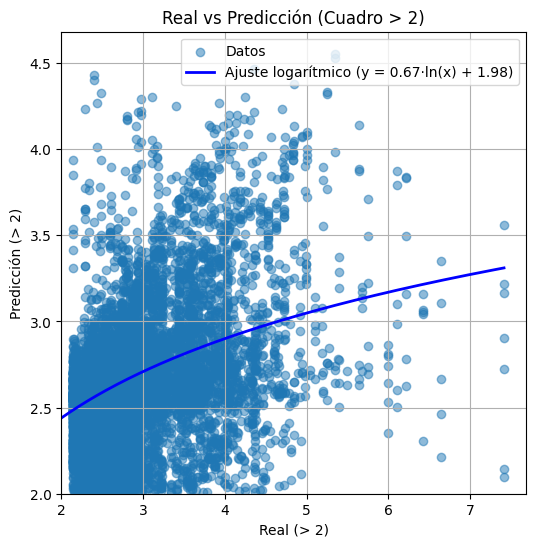

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Convertir a numpy array para aplicar la máscara
y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred)

# Crear máscara: tanto la realidad como la predicción deben ser > 2
mask = (y_test_arr > 2) & (y_pred_arr > 2)

y_test_filt = y_test_arr[mask]
y_pred_filt = y_pred_arr[mask]

plt.figure(figsize=(6, 6))

# 1. Dibujar puntos filtrados
plt.scatter(y_test_filt, y_pred_filt, alpha=0.5, label='Datos')

# Límites para el eje X
min_val = 2
max_val = max(y_test_filt.max(), y_pred_filt.max())

# 2. Ajuste logarítmico: y = a * ln(x) + b
a, b = np.polyfit(np.log(y_test_filt), y_pred_filt, 1)

# Generar puntos para trazar una curva suave
x_trend = np.linspace(min_val, max_val, 200)
y_trend = a * np.log(x_trend) + b

# 3. Dibujar la línea de tendencia logarítmica
plt.plot(x_trend, y_trend, color='blue', linewidth=2, label=f'Ajuste logarítmico (y = {a:.2f}·ln(x) + {b:.2f})')

# Fijar el inicio de los ejes en 2
plt.xlim(left=2)
plt.ylim(bottom=2)

plt.xlabel('Real (> 2)')
plt.ylabel('Predicción (> 2)')
plt.title('Real vs Predicción (Cuadro > 2)')
plt.legend()
plt.grid(True)
plt.show()

🔍 Tuneando Árbol de Decisión...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Mejores parámetros: {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
📊 Mejor MSE (validación): 0.4631

=== Métricas en Test ===
Test MSE: 0.5530
Test MAE: 0.3339
Test R2:  0.4650

=== Importancia de Características ===
               feature  importance
0   target_reg_enc_30d    0.753685
13  days_since_last_eq    0.195181
5                  gap    0.051059
9   adj_roll30_energia    0.000075


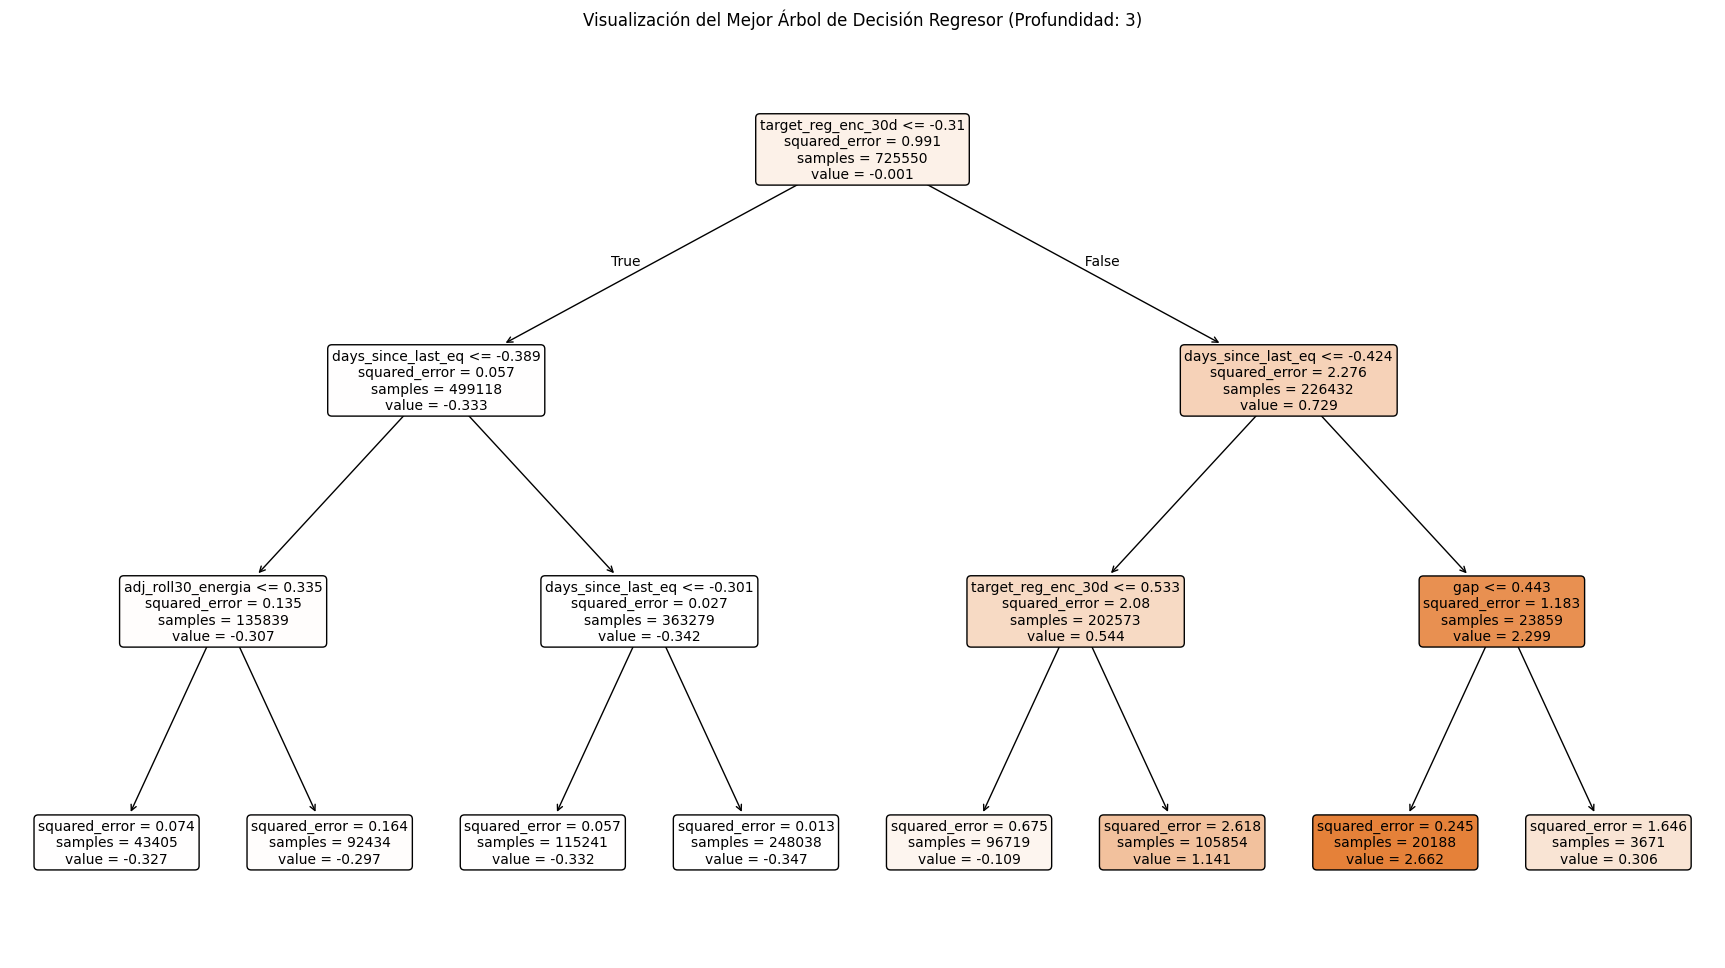

In [12]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

# === OPCIONES DE BÚSQUEDA (GRID SEARCH) ===
param_grid_dt = {
    'max_depth': [3],          # Profundidad máxima (baja para poder visualizarlo)
    'max_features': [None, 8],    # Número de variables a considerar
    'min_samples_leaf': [10, 20], # Tamaño mínimo del nodo hijo (min.node.size)
    'min_samples_split': [2, 10]  # Tamaño mínimo del nodo para dividir
}

tscv = TimeSeriesSplit(n_splits=5)
scoring = {
    'MSE': 'neg_mean_squared_error',
    'MAE': 'neg_mean_absolute_error', 
    'R2': 'r2'
}

# === CONFIGURAR GRID SEARCH ===
grid_search_dt = GridSearchCV(
    DecisionTreeRegressor(
        random_state=42,          # Semilla para reproducibilidad
        criterion='squared_error' # Medida de calidad de la división
    ),
    param_grid=param_grid_dt,
    cv=tscv,
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    refit='MSE'                   # Re-fitear el mejor modelo usando 'MSE'
)

# === EJECUTAR TUNEO ===
print("🔍 Tuneando Árbol de Decisión...")
grid_search_dt.fit(X_train, y_train)

print(f"\n✅ Mejores parámetros: {grid_search_dt.best_params_}")
# Nota: Scikit-learn devuelve el MSE en negativo cuando se usa 'neg_mean_squared_error', por eso el signo '-'
print(f"📊 Mejor MSE (validación): {-grid_search_dt.best_score_:.4f}")

# === EVALUAR EN TEST ===
best_dt = grid_search_dt.best_estimator_
y_pred = best_dt.predict(X_test)

print("\n=== Métricas en Test ===")
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Test R2:  {r2_score(y_test, y_pred):.4f}")

# Importancia de características
# Asumiendo que X_train es un DataFrame. Si es un array, sustituye X_train.columns por tu lista de variables (ej. listconti2)
importances = pd.DataFrame({
    'feature': X_train.columns, 
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Importancia de Características ===")
print(importances[importances['importance'] > 0]) # Mostrar solo las que aportaron al modelo

# === VISUALIZACIÓN DEL MEJOR ÁRBOL ===
plt.figure(figsize=(22, 12))    # Ajustar tamaño según la profundidad elegida
plot_tree(
    best_dt, 
    feature_names=X_train.columns,  # Nombres de las variables
    filled=True,                    # Colorear nodos (más oscuro = valor de predicción más alto/bajo)
    rounded=True,                   # Bordes redondeados en las cajas
    fontsize=10,                    # Tamaño de letra
    precision=3                     # Cantidad de decimales a mostrar en el valor
)
plt.title(f"Visualización del Mejor Árbol de Decisión Regresor (Profundidad: {best_dt.max_depth})")
plt.show()

In [8]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    scoring='neg_mean_squared_error',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print(perm_importance)

target_reg_enc_30d    3.697308
days_since_last_eq    1.249409
roll30_eq_count       0.416220
roll30_energia        0.243953
roll30_mag_max        0.103514
gap                   0.015533
roll7_eq_count        0.009522
eq_count              0.006469
adj_roll30_energia    0.003800
rms                   0.003646
roll7_energia         0.003137
adj_roll30_mag_max    0.002838
lat                   0.001912
main_depth            0.001237
locationSource_ci     0.000014
dtype: float64


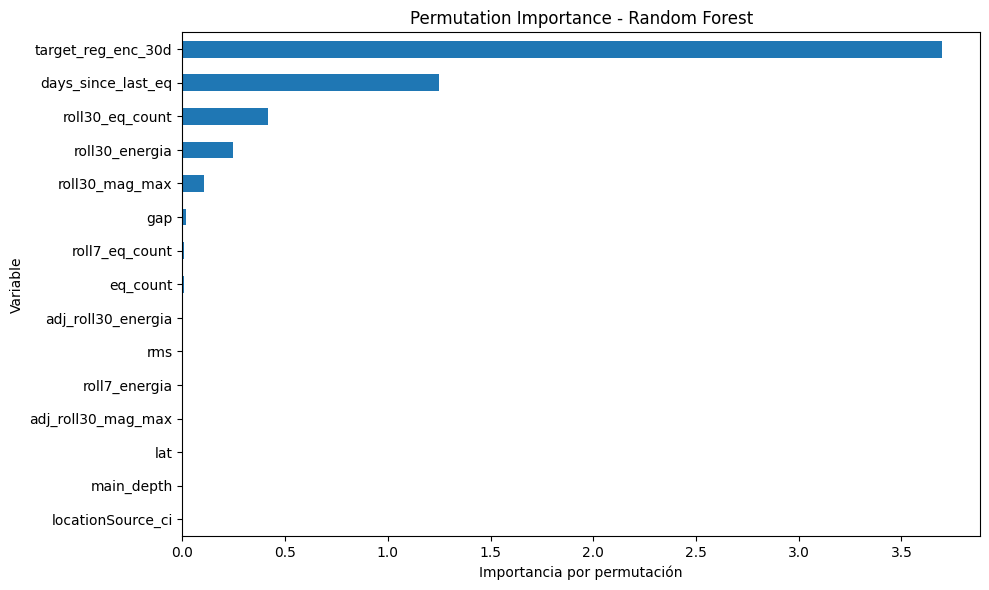

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

perm_importance.sort_values().plot(
    kind='barh'
)

plt.xlabel("Importancia por permutación")
plt.ylabel("Variable")
plt.title("Permutation Importance - Random Forest")
plt.tight_layout()
plt.show()

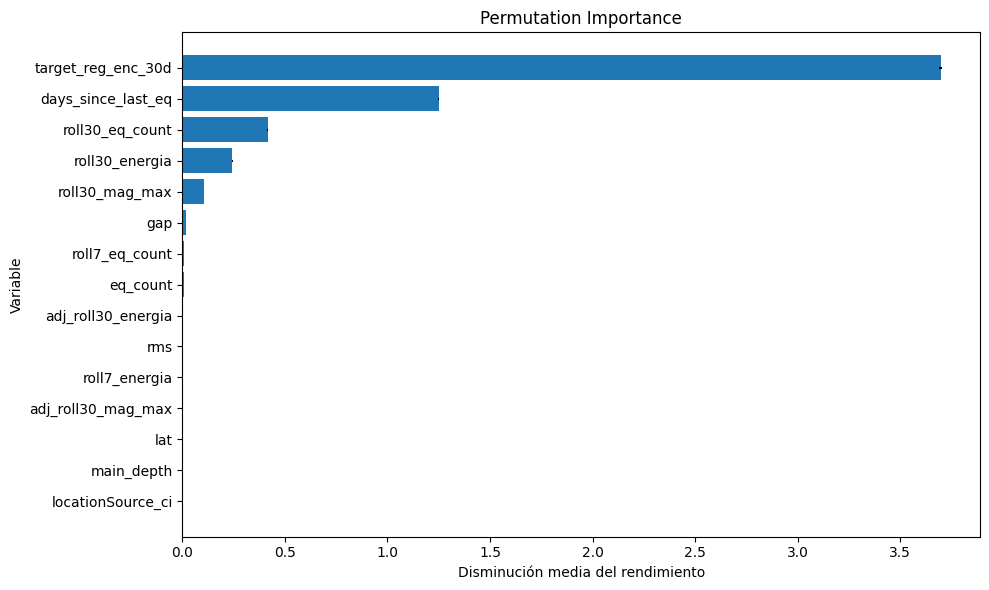

In [11]:
import numpy as np

sorted_idx = np.argsort(perm.importances_mean)

plt.figure(figsize=(10, 6))

plt.barh(
    range(len(sorted_idx)),
    perm.importances_mean[sorted_idx],
    xerr=perm.importances_std[sorted_idx]
)

plt.yticks(
    range(len(sorted_idx)),
    X_test.columns[sorted_idx]
)

plt.xlabel("Disminución media del rendimiento")
plt.ylabel("Variable")
plt.title("Permutation Importance")
plt.tight_layout()
plt.show()

In [9]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\longj\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import shap

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)

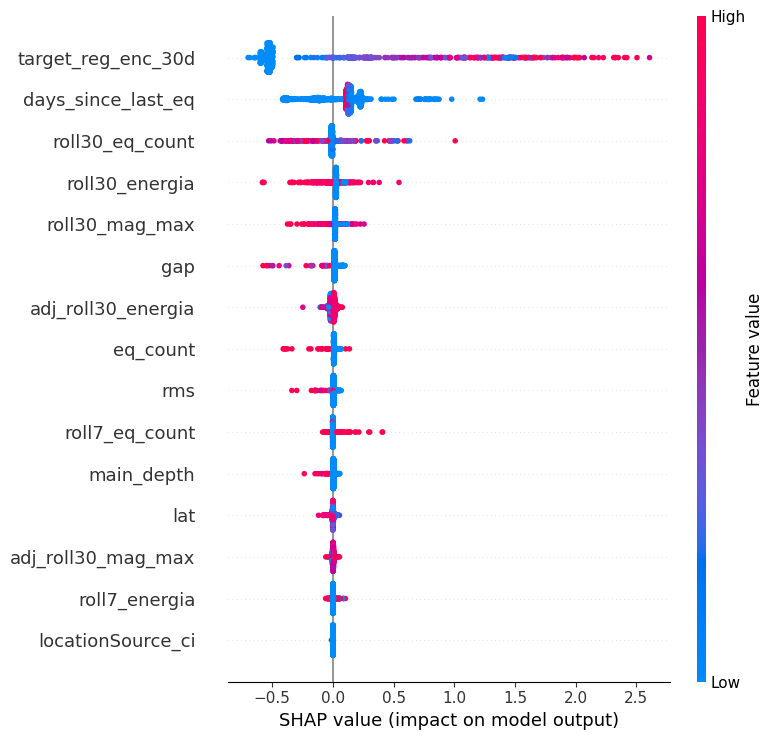

In [10]:
import shap

X_shap = X_test.sample(n=1000, random_state=42)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap)

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

In [ ]:
grid_search_results = pd.DataFrame(grid_search.cv_results_)

In [ ]:
columnas_esperadas = [
    'param_hidden_layer_sizes', 'param_alpha', 'param_max_iter',
    'param_n_estimators', 'param_max_features', 'param_min_samples_leaf', 'param_max_depth',
    'mean_test_MSE', 'std_test_MSE',
    'mean_test_score', 'std_test_score', 'mean_test_MSE',
                           'std_test_MSE',
                           'mean_test_MAE',
                           'std_test_MAE',
                           'mean_test_R2',
                           'std_test_R2'
]

columnas_a_mostrar = [c for c in columnas_esperadas if c in grid_search_results.columns]

if len(columnas_a_mostrar) == 0:
    print("No se encontraron las columnas esperadas. Columnas disponibles:")
    print(grid_search_results.columns.tolist())
else:
    print(grid_search_results[columnas_a_mostrar])

In [ ]:
y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

metricas_train = calcular_metricas(y_train, y_pred_train)
metricas_test = calcular_metricas(y_test, y_pred_test)

In [ ]:
print(metricas_train)
print(metricas_test)

GBM

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 4, 6],               # interaction.depth
    'min_samples_leaf': [5, 10, 20],      # n.minobsinnode
    'learning_rate': [0.001, 0.01, 0.05, 0.1],  # shrinkage
    'n_estimators': [50, 100, 200, 500, 1000]   # n.trees
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("🔍 Tuneando GBM (equivalente a gbm de R)...")
grid_search.fit(X_tuneo, y_tuneo)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor MSE (validación): {grid_search.best_score_:.4f}")

best_gbm = grid_search.best_estimator_
y_pred = best_gbm.predict(X_test)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

resultados = pd.DataFrame(grid_search.cv_results_)
resultados["MSE"] = -resultados["mean_test_score"]
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=resultados,
    x='param_n_estimators',
    y='MSE',
    hue='param_learning_rate',
    style='param_max_depth',
    size='param_min_samples_leaf',
    palette='viridis',
    sizes=(30, 200),
    alpha=0.8
)

plt.title("GBM Hyperparameter Performance Landscape")
plt.xlabel("n_estimators (n.trees)")
plt.ylabel("CV Score (MSE)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [ ]:
df_200 = resultados[resultados["param_n_estimators"] == 200].copy()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_200,
    x='param_learning_rate',
    y='MSE',
    hue='param_max_depth',
    style='param_min_samples_leaf',
    size='param_min_samples_leaf',
    palette='viridis',
    alpha=0.8
)

plt.title("GBM Performance (solo n_estimators = 200)")
plt.xlabel("learning_rate (shrinkage)")
plt.ylabel("MSE (CV)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
selected_configs = [
    {"param_n_estimators": 200, "param_learning_rate": 0.01, "param_max_depth": 6, "param_min_samples_leaf": 20},
    {"param_n_estimators": 200, "param_learning_rate": 0.01, "param_max_depth": 6, "param_min_samples_leaf": 10},
    {"param_n_estimators": 200, "param_learning_rate": 0.05, "param_max_depth": 6, "param_min_samples_leaf": 10},
]

In [ ]:
mask = pd.Series(False, index=resultados.index)

for cfg in selected_configs:
    cond = True
    for k, v in cfg.items():
        cond = cond & (resultados[k] == v)
    mask = mask | cond

filtered = resultados[mask].copy()

rows = []

for _, row in filtered.iterrows():
    model_name = str(row["params"])  # o puedes simplificarlo
    for fold in range(5):
        rows.append({
            "model": model_name,
            "fold": fold,
            "MSE": -row[f"split{fold}_test_score"]
        })

df_box = pd.DataFrame(rows)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_box,
    x="model",
    y="MSE"
)

sns.stripplot(
    data=df_box,
    x="model",
    y="MSE",
    color="black",
    alpha=0.5
)

plt.xticks(rotation=45, ha="right")
plt.title("Comparación de configuraciones GBM (CV folds)")
plt.show()

In [ ]:
df_box

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
scoring ={
    'MSE': 'neg_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}
param_grid = {
    'max_depth': [ 6],               # interaction.depth
    'min_samples_leaf': [ 20],      # n.minobsinnode
    'learning_rate': [ 0.01],  # shrinkage
    'n_estimators': [ 200]   # n.trees
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=tscv,
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("🔍 Tuneando GBM (equivalente a gbm de R)...")
grid_search.refit = 'MSE'  # Asegurarse de que GridSearchCV re-fitee usando la métrica 'MSE' al usar scoring multi-métrica
grid_search.fit(X_train, y_train)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor MSE (validación): {grid_search.best_score_:.4f}")

best_gbm = grid_search.best_estimator_
y_pred = best_gbm.predict(X_test)

In [ ]:
grid_search_results = pd.DataFrame(grid_search.cv_results_)
columnas_esperadas = [
    'param_hidden_layer_sizes', 'param_alpha', 'param_max_iter',
    'param_n_estimators', 'param_max_features', 'param_min_samples_leaf', 'param_max_depth',
    'mean_test_MSE', 'std_test_MSE',
    'mean_test_score', 'std_test_score', 'mean_test_MSE',
                           'std_test_MSE',
                           'mean_test_MAE',
                           'std_test_MAE',
                           'mean_test_R2',
                           'std_test_R2'
]

columnas_a_mostrar = [c for c in columnas_esperadas if c in grid_search_results.columns]

if len(columnas_a_mostrar) == 0:
    print("No se encontraron las columnas esperadas. Columnas disponibles:")
    print(grid_search_results.columns.tolist())
else:
    print(grid_search_results[columnas_a_mostrar])

In [ ]:
y_pred_train = best_gbm.predict(X_train)

metricas_train = calcular_metricas(y_train, y_pred_train)
metricas_test = calcular_metricas(y_test, y_pred)
print(metricas_train)
print(metricas_test)

XGB

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200, 500, 1000],
    "learning_rate": [0.001, 0.01, 0.05, 0.1],
    "max_depth": [2, 4, 6],
    "min_child_weight": [1, 5, 10, 20]
}

grid_search = GridSearchCV(
    XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_tuneo, y_tuneo)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor MSE (validación): {grid_search.best_score_:.4f}")



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

resultados = pd.DataFrame(grid_search.cv_results_)
resultados["MSE"] = -resultados["mean_test_score"]
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=resultados,
    x='param_n_estimators',
    y='MSE',
    hue='param_learning_rate',
    style='param_max_depth',
    size='param_min_child_weight',
    palette='viridis',
    sizes=(30, 200),
    alpha=0.8
)

plt.title("XGB Hyperparameter Performance Landscape")
plt.xlabel("n_estimators (n.trees)")
plt.ylabel("CV Score (MSE)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
df_200 = resultados[resultados["param_n_estimators"] == 200].copy()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_200,
    x='param_learning_rate',
    y='MSE',
    hue='param_max_depth',
    style='param_min_child_weight',
    size='param_min_child_weight',
    palette='viridis',
    alpha=0.8
)

plt.title("XGB Performance (solo n_estimators = 200)")
plt.xlabel("learning_rate (shrinkage)")
plt.ylabel("MSE (CV)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
param_grid = {
    "n_estimators": [ 200],
    "learning_rate": [ 0.01],
    "max_depth": [6],
    "min_child_weight": [10]
}

grid_search = GridSearchCV(
    XGBRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring=scoring,
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


print("🔍 Tuneando XGB (equivalente a xgboost de R)...")
grid_search.refit = 'MSE'  # Asegurarse de que GridSearchCV re-fitee usando la métrica 'MSE' al usar scoring multi-métrica
grid_search.fit(X_train, y_train)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor MSE (validación): {grid_search.best_score_:.4f}")

best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)


In [ ]:
grid_search_results = pd.DataFrame(grid_search.cv_results_)

In [ ]:
columnas_esperadas = [
    'param_hidden_layer_sizes', 'param_alpha', 'param_max_iter',
    'param_n_estimators', 'param_max_features', 'param_min_samples_leaf', 'param_max_depth',
    'mean_test_MSE', 'std_test_MSE',
    'mean_test_score', 'std_test_score', 'mean_test_MSE',
                           'std_test_MSE',
                           'mean_test_MAE',
                           'std_test_MAE',
                           'mean_test_R2',
                           'std_test_R2'
]

columnas_a_mostrar = [c for c in columnas_esperadas if c in grid_search_results.columns]

if len(columnas_a_mostrar) == 0:
    print("No se encontraron las columnas esperadas. Columnas disponibles:")
    print(grid_search_results.columns.tolist())
else:
    print(grid_search_results[columnas_a_mostrar])

In [ ]:
y_pred_train = best_xgb.predict(X_train)
y_pred_test = best_xgb.predict(X_test)

metricas_train = calcular_metricas(y_train, y_pred_train)
metricas_test = calcular_metricas(y_test, y_pred_test)

In [ ]:
print(metricas_train)
print(metricas_test)

KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": [3, 5, 7, 11, 15, 21, 31],
    "weights": ["uniform", "distance"],
    "p": [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_tuneo, y_tuneo)

In [ ]:

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor MSE (validación): {grid_search.best_score_:.4f}")

best_knn = grid_search.best_estimator_

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

resultados = pd.DataFrame(grid_search.cv_results_)
resultados["MSE"] = -resultados["mean_test_score"]

plt.figure(figsize=(10,6))

sns.lineplot(
    data=resultados,
    x="param_n_neighbors",
    y="MSE",
    hue="param_weights",     # color
    style="param_p",         # tipo de línea
    markers=True
)

plt.title("KNN Performance vs número de vecinos")
plt.xlabel("n_neighbors")
plt.ylabel("MSE (CV)")
plt.show()

In [ ]:
param_grid = {
    "n_neighbors": [ 15],
    "weights": ["uniform"],
    "p": [2]  # 1 = Manhattan, 2 = Euclidean
}

grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor MSE (validación): {grid_search.best_score_:.4f}")

best_knn = grid_search.best_estimator_

In [ ]:
y_pred_train = best_knn.predict(X_train)
y_pred_test = best_knn.predict(X_test)

metricas_train = calcular_metricas(y_train, y_pred_train)
metricas_test = calcular_metricas(y_test, y_pred_test)

In [ ]:
print(metricas_train)
print(metricas_test)

Regresión lineal

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

param_grid = {
    "model": [ElasticNet(max_iter=10000)],

    # α (regularización total)
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],

    # λ (mezcla L1/L2)
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_search = GridSearchCV(
    Pipeline([("model", ElasticNet(max_iter=10000))]),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)

grid_search.fit(X_tuneo, y_tuneo)

print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor MSE (validación): {grid_search.best_score_:.4f}")

In [ ]:
param_grid = {
    "model": [ElasticNet(max_iter=10000)],

    # α (regularización total)
    "model__alpha": [0.01],

    # λ (mezcla L1/L2)
    "model__l1_ratio": [0.9]
}

grid_search = GridSearchCV(
    Pipeline([("model", ElasticNet(max_iter=10000))]),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


print(f"\n✅ Mejores parámetros: {grid_search.best_params_}")
print(f"📊 Mejor MSE (validación): {grid_search.best_score_:.4f}")

best_reg = grid_search.best_estimator_

In [ ]:
y_pred_train = best_reg.predict(X_train)
y_pred_test = best_reg.predict(X_test)

metricas_train = calcular_metricas(y_train, y_pred_train)
metricas_test = calcular_metricas(y_test, y_pred_test)

print(metricas_train)
print(metricas_test)

svr

svr lineal


In [8]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.svm import LinearSVR

tscv = TimeSeriesSplit(n_splits=5)

param_grid_linear = {
    'C': [0.01, 0.1, 0.2, 0.5,1,2]
}

grid_linear = GridSearchCV(
    LinearSVR(max_iter=100000, random_state=42),
    param_grid=param_grid_linear,
    scoring='neg_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_linear.fit(X_tuneo, y_tuneo)

print("Mejores parámetros:", grid_linear.best_params_)
print("Mejor MSE CV:", -grid_linear.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores parámetros: {'C': 0.2}
Mejor MSE CV: 0.7204580336481705


In [18]:
y_pred_train = grid_linear.predict(X_train)
y_pred_test = grid_linear.predict(X_test)

metricas_train = calcular_metricas(y_train, y_pred_train)
metricas_test = calcular_metricas(y_test, y_pred_test)

print(metricas_train)
print(metricas_test)

{'RMSE': np.float64(1.0552381202380865), 'MSE': 1.1135274904036103, 'MAE': 0.3498686522721311, 'R2': -0.1235062054944065, 'MAPE': np.float64(12.765282611309)}
{'RMSE': np.float64(1.0775341057083563), 'MSE': 1.1610797489647073, 'MAE': 0.3568974531166536, 'R2': -0.12322607768208771, 'MAPE': np.float64(12.809484169040386)}


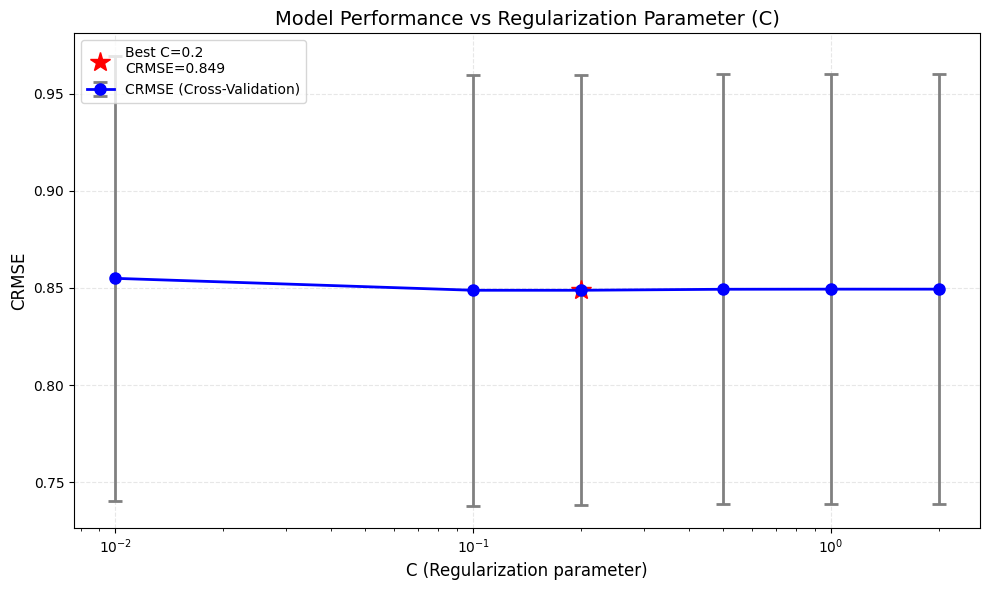


Resultados:
----------------------------------------
C          CRMSE     
----------------------------------------
0.010      0.855     
0.100      0.849     
0.200      0.849     
0.500      0.849     
1.000      0.849     
2.000      0.849     
----------------------------------------


In [10]:
import matplotlib.pyplot as plt
# --- CÓDIGO PARA EL PLOT ---
# Extraer los resultados
C_values = param_grid_linear['C']
mean_test_mse = -grid_linear.cv_results_['mean_test_score']  # Convertir a MSE positivo
std_test_mse = grid_linear.cv_results_['std_test_score']

# Calcular CRMSE (Root Mean Squared Error)
mean_test_rmse = np.sqrt(mean_test_mse)
std_test_rmse = std_test_mse / (2 * np.sqrt(mean_test_mse))  # Propagación de error aproximada

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.errorbar(C_values, mean_test_rmse, yerr=std_test_rmse, 
             fmt='o-', capsize=5, capthick=2, 
             markersize=8, linewidth=2, 
             color='blue', ecolor='gray', 
             label='CRMSE (Cross-Validation)')

plt.xscale('log')  # Escala logarítmica como en la imagen
plt.xlabel('C (Regularization parameter)', fontsize=12)
plt.ylabel('CRMSE', fontsize=12)
plt.title('Model Performance vs Regularization Parameter (C)', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()

# Marcar el mejor parámetro
best_C = grid_linear.best_params_['C']
best_rmse = np.sqrt(-grid_linear.best_score_)
plt.plot(best_C, best_rmse, 'r*', markersize=15, 
         label=f'Best C={best_C}\nCRMSE={best_rmse:.3f}')
plt.legend()

plt.tight_layout()
plt.show()

# Imprimir tabla como en la imagen
print("\nResultados:")
print("-" * 40)
print(f"{'C':<10} {'CRMSE':<10}")
print("-" * 40)
for c, rmse in zip(C_values, mean_test_rmse):
    print(f"{c:<10.3f} {rmse:<10.3f}")
print("-" * 40)

In [12]:
from sklearn.svm import SVR


param_grid_poly = {
    'C': [0.01, 0.1,0.5,1, 5],
    'degree': [2, 3, 4],
    'gamma': [0.001, 0.01, 0.1, 1]  # Ajuste de gamma para el kernel polinómico
}

grid_poly = GridSearchCV(
    SVR(
    kernel='poly',
    max_iter=10000,  # Límite de 1000 iteraciones
),
    param_grid=param_grid_poly,
    scoring='neg_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_poly.fit(X_tuneo, y_tuneo)

print("Mejores parámetros:", grid_poly.best_params_)
print("Mejor MSE CV:", -grid_poly.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Mejores parámetros: {'C': 5, 'degree': 2, 'gamma': 0.01}
Mejor MSE CV: 0.6926898137535774


C:\Users\longj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [19]:
y_pred_train = grid_poly.predict(X_train)
y_pred_test = grid_poly.predict(X_test)

metricas_train = calcular_metricas(y_train, y_pred_train)
metricas_test = calcular_metricas(y_test, y_pred_test)

print(metricas_train)
print(metricas_test)

{'RMSE': np.float64(4.618556884465754), 'MSE': 21.331067695046013, 'MAE': 0.3985052217745209, 'R2': -20.522222964175647, 'MAPE': np.float64(32.730193861665306)}
{'RMSE': np.float64(33.60198516485755), 'MSE': 1129.0934070193068, 'MAE': 0.6040514937471615, 'R2': -1091.282558570015, 'MAPE': np.float64(36.53897145512695)}


In [15]:
from sklearn.svm import SVR

param_grid_rbf = {
    'C': [0.01, 0.1,0.5,1, 5, 10],
    'gamma': [0.0001, 0.001, 0.01, 0.1, 1],
}

grid_rbf = GridSearchCV(
    SVR(
    kernel='rbf',
    max_iter=10000,  # Límite de 1000 iteraciones
),
    param_grid=param_grid_rbf,
    scoring='neg_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_rbf.fit(X_tuneo, y_tuneo)

print("Mejores parámetros:", grid_rbf.best_params_)
print("Mejor MSE CV:", -grid_rbf.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores parámetros: {'C': 5, 'gamma': 0.1}
Mejor MSE CV: 0.5232360087448023


C:\Users\longj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


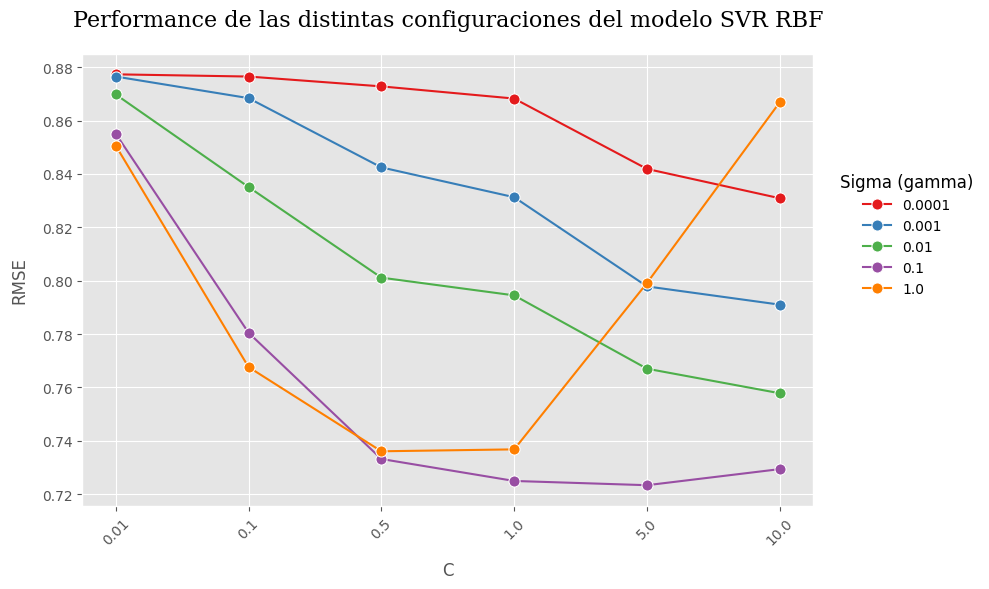

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Extraer los resultados del GridSearchCV
resultados = grid_rbf.cv_results_

# 2. Crear un DataFrame con los parámetros y el score
df_resultados = pd.DataFrame({
    'C': resultados['param_C'],
    'gamma': resultados['param_gamma'],
    # Convertimos el MSE negativo a MSE positivo y aplicamos la raíz cuadrada para el RMSE
    'RMSE': np.sqrt(-resultados['mean_test_score'])
})

# Convertimos C a string (categoría) para que el eje X quede espaciado de manera uniforme 
# igual que en tu imagen de referencia, sin importar el salto numérico entre valores.
df_resultados['C_str'] = df_resultados['C'].astype(str)

# 3. Configurar el estilo del gráfico (estilo R/ggplot)
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Crear el gráfico de líneas con seaborn
sns.lineplot(
    data=df_resultados,
    x='C_str',
    y='RMSE',
    hue='gamma',
    palette='Set1', # Paleta de colores similar a la de tu imagen
    marker='o',     # Añadir el punto en cada intersección
    markersize=8,
    linewidth=1.5,
    ax=ax
)

# 5. Personalización de etiquetas y título
ax.set_title('Performance de las distintas configuraciones del modelo SVR RBF', 
             pad=20, fontsize=16, fontfamily='serif')
ax.set_xlabel('C', labelpad=10, fontsize=12)
ax.set_ylabel('RMSE', labelpad=10, fontsize=12)

# Rotar las etiquetas del eje X a 45 grados
plt.xticks(rotation=45)

# 6. Formatear la leyenda (moverla a la derecha fuera del gráfico)
plt.legend(title='Sigma (gamma)', bbox_to_anchor=(1.02, 0.6), loc='center left', 
           frameon=False, title_fontsize=12)

# 7. Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()

In [21]:
from sklearn.svm import SVR

param_grid_rbf = {
    'C': [ 5],
    'gamma': [ 0.1],
}

grid_rbf = GridSearchCV(
    SVR(
    kernel='rbf',
    max_iter=10000,  # Límite de 1000 iteraciones
),
    param_grid=param_grid_rbf,
    scoring='neg_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_rbf.fit(X_train, y_train)


y_pred_train = grid_rbf.predict(X_train)
y_pred_test = grid_rbf.predict(X_test)

metricas_train = calcular_metricas(y_train, y_pred_train)
metricas_test = calcular_metricas(y_test, y_pred_test)

print(metricas_train)
print(metricas_test)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\longj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


{'RMSE': np.float64(3.3206733003645184), 'MSE': 11.026871167753782, 'MAE': 3.0303557894772557, 'R2': -10.12568687430275, 'MAPE': np.float64(766.9794816847311)}
{'RMSE': np.float64(3.3011712337103933), 'MSE': 10.897731514277, 'MAE': 3.025785000442844, 'R2': -9.5424422700752, 'MAPE': np.float64(766.3903377731509)}
